In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vbookshelf/respiratory-sound-database \
       -p /content/icbhi_dataset/raw --unzip --quiet

print("Download complete.")

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/respiratory-sound-database
License(s): unknown
Download complete.


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import librosa                        # audio loading, analysis
import librosa.display                # waveform/spectrogram plotting
import soundfile as sf                # reliable .wav read/write
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from collections import Counter
from IPython.display import Audio, display

In [ ]:
CONFIG = {
    "raw_dir" : "/content/icbhi_dataset/raw/Respiratory_Sound_Database/Respiratory_Sound_Database",
    "cycles_dir" : "/content/icbhi_dataset/cycles",
    "splits_file": "/content/icbhi_dataset/raw/Respiratory_Sound_Database/ICBHI_challenge_train_test.txt",
    "target_sr" : 22050,
    "class_map"  : {
        (0, 0): "Normal",
        (1, 0): "Crackle",
        (0, 1): "Wheeze",
        (1, 1): "Both",
    },
    "classes"    : ["Normal", "Crackle", "Wheeze", "Both"],
    "seed"       : 42
}

In [ ]:
for d in [CONFIG["raw_dir"], CONFIG["cycles_dir"]]:
    os.makedirs(d, exist_ok=True)

print("CONFIG ready.")
print(f"Target sample rate : {CONFIG['target_sr']} Hz")
print(f"Classes            : {CONFIG['classes']}")

CONFIG ready.
Target sample rate : 22050 Hz
Classes            : ['Normal', 'Crackle', 'Wheeze', 'Both']


In [ ]:
def parse_annotation_file(txt_path: str) -> pd.DataFrame:
  df = pd.read_csv(
        txt_path,
        sep = "\t",
        header=None,
        names = ["start", "end", "crackle", "wheeze"]
                 )
  """
    Read one ICBHI annotation .txt file and return a DataFrame.

    Args:
        txt_path: path to the .txt annotation file

    Returns:
        DataFrame with columns:
            start    → cycle start time in seconds (float)
            end      → cycle end time in seconds (float)
            crackle  → 1 if crackles present, else 0 (int)
            wheeze   → 1 if wheeze present, else 0 (int)
            label    → human-readable class string ("Normal", "Crackle", etc.)
    """
    # Convert crackle/wheeze to int (sometimes read as float)
  df["crackle"] = df["crackle"].astype(int)
  df["wheeze"]  = df["wheeze"].astype(int)

  # Map (crackle, wheeze) turple -> class string using CONFIG
  df["label"] = df.apply(
      lambda row: CONFIG["class_map"][(row["crackle"], row["wheeze"])],
      axis=1
  )
  return df


In [ ]:
def demo_annotation_parsing(raw_dir: str):
    """Show the first annotation file we find."""
    audio_dir = os.path.join(raw_dir, "audio_and_txt_files")

    # Find any .txt file
    txt_files = list(Path(audio_dir).glob("*.txt"))
    if not txt_files:
        print("No annotation files found. Check your raw_dir path.")
        return

    sample_txt = str(txt_files[0])
    print(f"Parsing: {os.path.basename(sample_txt)}\n")

    df = parse_annotation_file(sample_txt)
    print(df.to_string(index=False))
    print(f"\nCycles in this recording: {len(df)}")
    print(f"Label counts: {df['label'].value_counts().to_dict()}")


demo_annotation_parsing(CONFIG["raw_dir"])

Parsing: 156_2b3_Ll_mc_AKGC417L.txt

 start    end  crackle  wheeze label
 2.088  5.248        1       1  Both
 5.248  8.481        1       1  Both
 8.481 11.570        1       1  Both
11.570 14.535        1       1  Both
14.535 17.589        1       1  Both
17.589 19.961        1       1  Both

Cycles in this recording: 6
Label counts: {'Both': 6}


In [ ]:
def build_master_dataframe(raw_dir: str, splits_file: str) -> pd.DataFrame:
    """
    Parse all annotation files and combine into one master DataFrame.

    Also attaches:
        - patient_id  → extracted from filename (first number, e.g. "101")
        - split       → "train" or "test" from official ICBHI split file
        - wav_path    → full path to the source .wav file
        - txt_path    → full path to the annotation .txt file

    Args:
        raw_dir     : path to the raw dataset root
        splits_file : path to ICBHI_challenge_train_test.txt

    Returns:
        master DataFrame with one row per breathing cycle
    """
    audio_dir = os.path.join(raw_dir, "audio_and_txt_files")


    # The split file has one filename per line, labeled "train" or "test"
    # Format:  101_1b1_Al_sc_Litt3200   train
    split_df = pd.read_csv(
        splits_file,
        sep="\t",
        header=None,
        names=["filename", "split"]
    )
    # Build a dict: filename_stem → "train" or "test"
    split_dict = dict(zip(split_df["filename"], split_df["split"]))

    all_rows = []   # collect rows from every file

    txt_files = sorted(Path(audio_dir).glob("*.txt"))
    print(f"Found {len(txt_files)} annotation files...")

    for txt_path in txt_files:
        stem = txt_path.stem               # e.g. "101_1b1_Al_sc_Litt3200"
        wav_path = txt_path.with_suffix(".wav")  # matching .wav file

        if not wav_path.exists():
            # Skip if audio file missing (shouldn't happen in clean download)
            print(f"  WARNING: No .wav found for {stem}, skipping.")
            continue

        # Extract patient ID — always the first part before the first underscore
        patient_id = stem.split("_")[0]    # "101_1b1_..." → "101"

        # Get train/test label from the split dict
        split = split_dict.get(stem, "unknown")

        # Parse this file's annotation
        df = parse_annotation_file(str(txt_path))

        # Attach metadata columns to every row
        df["filename"]   = stem
        df["patient_id"] = patient_id
        df["split"]      = split
        df["wav_path"]   = str(wav_path)
        df["txt_path"]   = str(txt_path)

        all_rows.append(df)

    # Stack all individual DataFrames into one master table
    master = pd.concat(all_rows, ignore_index=True)

    # Add a unique cycle_id for each row (useful for saving files later)
    master["cycle_id"] = master.index

    print(f"\nMaster DataFrame built.")
    print(f"Total breathing cycles : {len(master)}")
    print(f"Unique patients        : {master['patient_id'].nunique()}")
    print(f"Train cycles           : {(master['split'] == 'train').sum()}")
    print(f"Test cycles            : {(master['split'] == 'test').sum()}")

    return master
master_df = build_master_dataframe(CONFIG["raw_dir"], CONFIG["splits_file"])

Found 920 annotation files...

Master DataFrame built.
Total breathing cycles : 6898
Unique patients        : 126
Train cycles           : 4131
Test cycles            : 2756


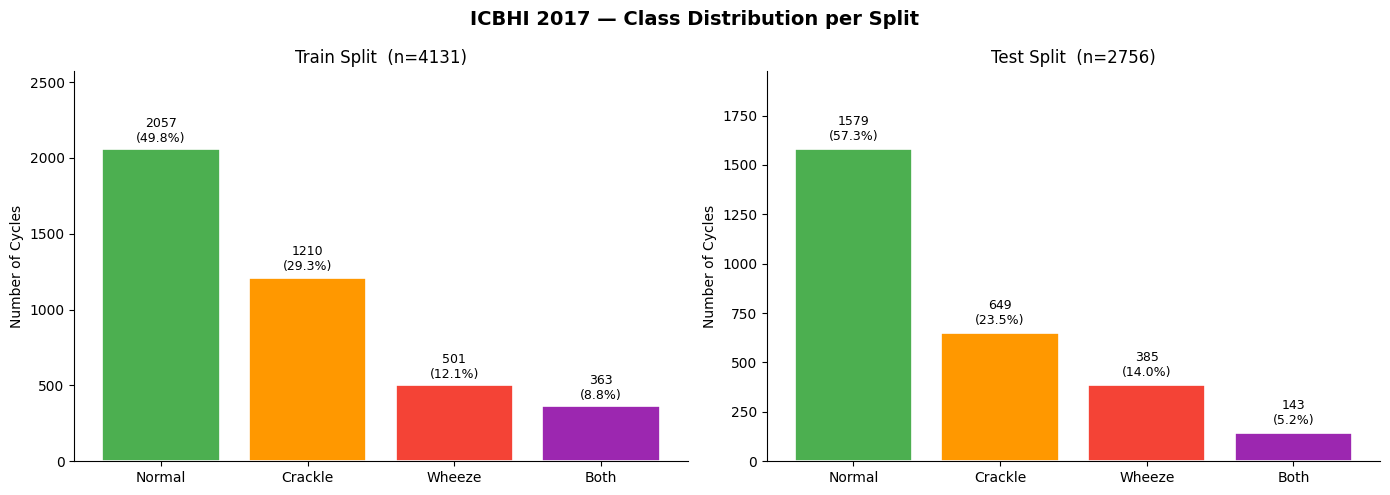


Key observation: Normal >> Crackle >> Wheeze >> Both
This imbalance is WHY WeightedRandomSampler + SpecAugment is needed in Phase 4.


In [ ]:
def plot_class_distribution(master_df: pd.DataFrame):
    """
    Plot class counts for train and test splits side by side.
    This is your first look at the imbalance problem.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("ICBHI 2017 — Class Distribution per Split", fontsize=14, fontweight="bold")

    colors = {
        "Normal" : "#4CAF50",   # green — healthy
        "Crackle": "#FF9800",   # orange — abnormal
        "Wheeze" : "#F44336",   # red — abnormal
        "Both"   : "#9C27B0",   # purple — most severe
    }

    for ax, split in zip(axes, ["train", "test"]):
        split_df = master_df[master_df["split"] == split]
        counts   = split_df["label"].value_counts()

        # Reorder to match CONFIG["classes"] order
        counts = counts.reindex(CONFIG["classes"], fill_value=0)

        bars = ax.bar(
            counts.index,
            counts.values,
            color=[colors[c] for c in counts.index],
            edgecolor="white",
            linewidth=1.2
        )

        # Annotate each bar with its count and percentage
        total = counts.sum()
        for bar, count in zip(bars, counts.values):
            pct = 100 * count / total
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # x: center of bar
                bar.get_height() + 30,               # y: just above bar
                f"{count}\n({pct:.1f}%)",            # label text
                ha="center", va="bottom", fontsize=9
            )

        ax.set_title(f"{split.capitalize()} Split  (n={total})", fontsize=12)
        ax.set_ylabel("Number of Cycles")
        ax.set_ylim(0, counts.max() * 1.25)   # headroom for annotations
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nKey observation: Normal >> Crackle >> Wheeze >> Both")
    print("This imbalance is WHY WeightedRandomSampler + SpecAugment is needed in Phase 4.")

plot_class_distribution(master_df)

In [ ]:
path = "/content/icbhi_dataset/raw/Respiratory_Sound_Database/ICBHI_challenge_train_test.txt"

with open(path) as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("First 5 lines:")
for line in lines[:5]:
    print(repr(line))

Total lines: 920
First 5 lines:
'101_1b1_Al_sc_Meditron\ttest\n'
'101_1b1_Pr_sc_Meditron\ttest\n'
'102_1b1_Ar_sc_Meditron\ttest\n'
'103_2b2_Ar_mc_LittC2SE\ttrain\n'
'104_1b1_Al_sc_Litt3200\ttest\n'


In [ ]:
def demonstrate_audio_loading(wav_path: str, target_sr: int = 22050):
    """
    Load one .wav file and explain what librosa gives you.

    Args:
        wav_path  : path to any .wav file in the dataset
        target_sr : the sample rate to resample to
    """

    y, sr = librosa.load(
        wav_path,
        sr=target_sr,   # resample to 22050 Hz regardless of original rate
        mono=True
    )
    # y  → shape: (num_samples,) — the actual audio signal

    duration = len(y) / sr   # total duration in seconds


    print(f"File          : {os.path.basename(wav_path)}")
    print(f"Sample rate   : {sr} Hz")
    print(f"Num samples   : {len(y):,}")
    print(f"Duration      : {duration:.2f} seconds")
    print(f"y dtype       : {y.dtype}")
    print(f"y min/max     : {y.min():.4f} / {y.max():.4f}")
    print(f"y shape       : {y.shape}")
    print("\nIntuition:")
    print(f"  {sr} samples/sec × {duration:.1f} sec = {len(y):,} numbers")
    print(f"  Each number = air pressure at that instant (range: -1.0 to +1.0)")


    print("\nPlaying audio in Colab...")
    display(Audio(y, rate=sr))

    return y, sr

# Get a sample audio file path from the master_df
sample_wav_path = master_df["wav_path"].iloc[0]

demonstrate_audio_loading(sample_wav_path, 22050)

File          : 101_1b1_Al_sc_Meditron.wav
Sample rate   : 22050 Hz
Num samples   : 441,000
Duration      : 20.00 seconds
y dtype       : float32
y min/max     : -0.2001 / 0.4147
y shape       : (441000,)

Intuition:
  22050 samples/sec × 20.0 sec = 441,000 numbers
  Each number = air pressure at that instant (range: -1.0 to +1.0)

Playing audio in Colab...


(array([0.0699593 , 0.10248855, 0.09127858, ..., 0.08332463, 0.07993679,
        0.08635148], dtype=float32),
 22050)

In [73]:
# BREATHING CYCLE SEGMENTATION
# The ICBHI labels are per CYCLE, not per full recording.
# A full recording might be 20 seconds with 8 breathing cycles.
# We need to slice each cycle into its own audio clip.

def segment_and_save_cycles(master_df: pd.DataFrame, cycles_dir: str, target_sr: int):
  """
    For every row in master_df (= every breathing cycle):
        1. Load the source .wav
        2. Slice the audio between start_time and end_time
        3. Save as a new .wav file in cycles_dir/split/label/

    This creates the folder structure needed for ImageFolder later
    (after converts these to spectrograms).

    Args:
        master_df  : the master DataFrame from build_master_dataframe()
        cycles_dir : where to save segmented cycle .wav files
        target_sr  : sample rate to save at
    """

  # Cache loaded audio files to avoid re-reading the same .wav repeatedly.
  # One recording can have 8+ cycles — no need to reload 8 times.
  audio_cache = {}
  saved = 0
  skipped = 0

  for idx, row in master_df.iterrows():
    out_dir = os.path.join(cycles_dir, row["split"], row["label"])
    os.makedirs(out_dir, exist_ok=True)

    cycle_filename = f"{row['filename']}_cycle{row['cycle_id']:04d}.wav"
    out_path = os.path.join(out_dir, cycle_filename)

    if os.path.exists(out_path):
      skipped += 1
      continue

    wav_path = row["wav_path"]
    if wav_path not in audio_cache:
          y, sr = librosa.load(wav_path, sr=target_sr, mono=True)
          audio_cache[wav_path] = (y, sr)
    else:
        y, sr = audio_cache[wav_path]

    start_sample = int(row["start"] * sr)
    end_sample   = int(row["end"]   * sr)

    cycle_audio = y[start_sample:end_sample]


    min_samples = int(0.5 * sr)   # 0.5 seconds × 22050 = 11025 samples
    if len(cycle_audio) < min_samples:
          skipped += 1
          continue

    sf.write(out_path, cycle_audio, sr)   # soundfile handles wav encoding
    saved += 1

  print(f"\nSegmentation complete.")
  print(f"Saved   : {saved} cycles")
  print(f"Skipped : {skipped} cycles (already exist or too short)")

  # Show what the folder structure looks like
  print("\nFolder structure created:")
  for split in ["train", "test"]:
      for label in CONFIG["classes"]:
          folder = os.path.join(cycles_dir, split, label)
          if os.path.exists(folder):
              n = len(os.listdir(folder))
              print(f"  {split}/{label:<8} → {n} cycles")



segment_and_save_cycles(master_df=master_df, cycles_dir=CONFIG["cycles_dir"], target_sr=CONFIG["target_sr"])


Segmentation complete.
Saved   : 6857 cycles
Skipped : 41 cycles (already exist or too short)

Folder structure created:
  train/Normal   → 2031 cycles
  train/Crackle  → 1209 cycles
  train/Wheeze   → 499 cycles
  train/Both     → 363 cycles
  test/Normal   → 1571 cycles
  test/Crackle  → 647 cycles
  test/Wheeze   → 383 cycles
  test/Both     → 143 cycles


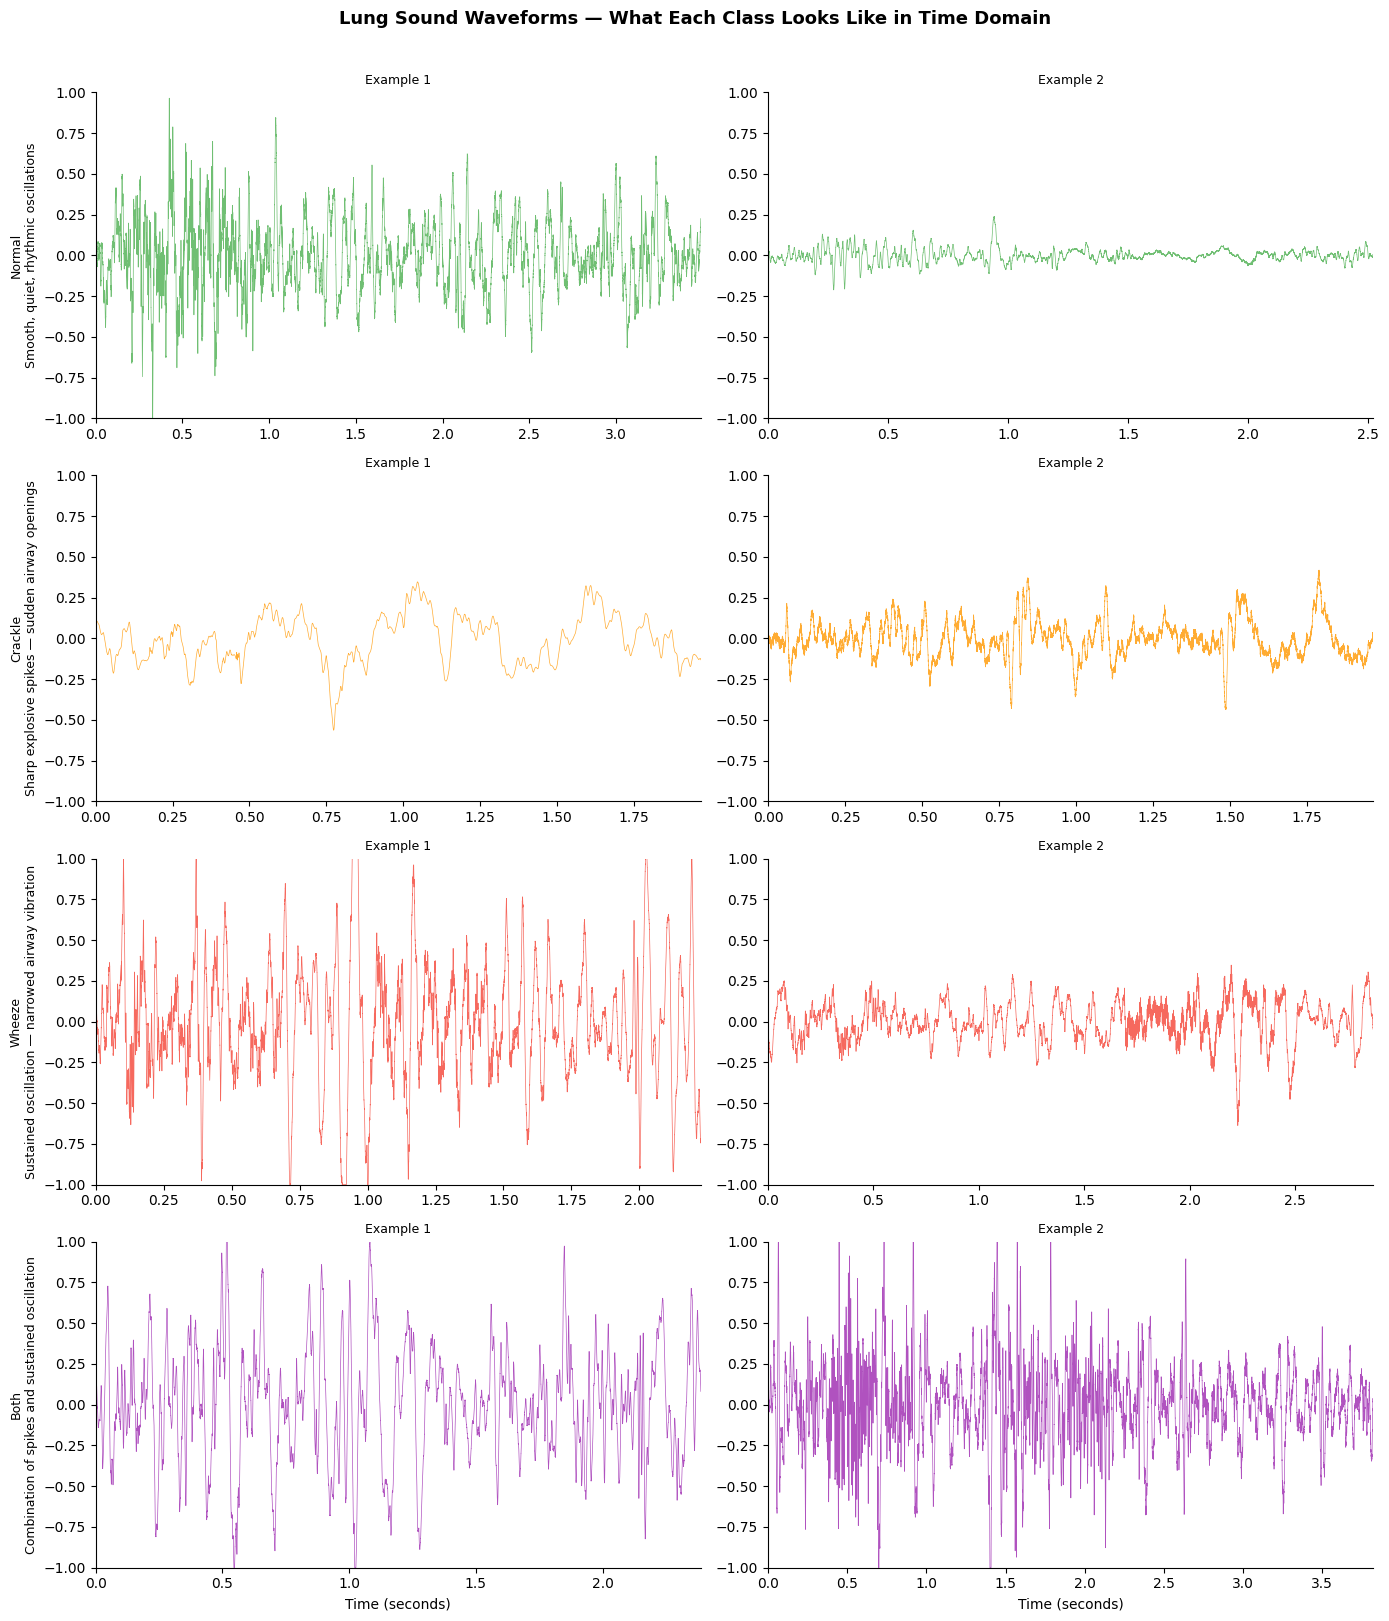

In [75]:
def plot_waveforms_by_class(cycles_dir: str, target_sr: int, num_examples: int = 2):
    """
    Plot sample waveforms for each class side by side.
    This is your intuition-building moment for the audio domain.

    Args:
        cycles_dir   : path to segmented cycles folder
        target_sr    : sample rate
        num_examples : how many examples to show per class
    """
    fig, axes = plt.subplots(
        len(CONFIG["classes"]), num_examples,
        figsize=(14, 4 * len(CONFIG["classes"]))
    )
    fig.suptitle(
        "Lung Sound Waveforms — What Each Class Looks Like in Time Domain",
        fontsize=13, fontweight="bold", y=1.01
    )

    class_descriptions = {
        "Normal" : "Smooth, quiet, rhythmic oscillations",
        "Crackle": "Sharp explosive spikes — sudden airway openings",
        "Wheeze" : "Sustained oscillation — narrowed airway vibration",
        "Both"   : "Combination of spikes and sustained oscillation",
    }

    np.random.seed(CONFIG["seed"])

    for row_idx, label in enumerate(CONFIG["classes"]):
        # Find available cycle files for this class (train split)
        class_folder = os.path.join(cycles_dir, "train", label)
        if not os.path.exists(class_folder):
            print(f"  No samples found for {label} yet. Run segmentation first.")
            continue

        wav_files = list(Path(class_folder).glob("*.wav"))
        if not wav_files:
            continue

        # Pick random examples
        chosen = np.random.choice(
            wav_files,
            size=min(num_examples, len(wav_files)),
            replace=False
        )

        for col_idx, wav_file in enumerate(chosen):
            ax = axes[row_idx][col_idx]

            # Load this cycle
            y, sr = librosa.load(str(wav_file), sr=target_sr)

            # Time axis in seconds
            time_axis = np.linspace(0, len(y) / sr, num=len(y))

            # Plot the waveform
            ax.plot(
                time_axis, y,
                linewidth=0.5,
                color=["#4CAF50","#FF9800","#F44336","#9C27B0"][row_idx],
                alpha=0.8
            )
            ax.set_xlim(0, len(y) / sr)
            ax.set_ylim(-1.0, 1.0)   # amplitude always in [-1, 1] after librosa

            # Labels
            if col_idx == 0:
                ax.set_ylabel(f"{label}\n{class_descriptions[label]}", fontsize=9)
            if row_idx == len(CONFIG["classes"]) - 1:
                ax.set_xlabel("Time (seconds)")

            ax.set_title(f"Example {col_idx + 1}", fontsize=9)
            ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("waveforms_by_class.png", dpi=150, bbox_inches="tight")
    plt.show()



plot_waveforms_by_class(cycles_dir=CONFIG["cycles_dir"], target_sr=CONFIG["target_sr"])

In [77]:
def play_class_examples(cycles_dir: str, target_sr: int):
    """
    Play one audio example per class directly in Colab.
    Run this cell and listen carefully to each sound.
    """
    np.random.seed(CONFIG["seed"])

    for label in CONFIG["classes"]:
        class_folder = os.path.join(cycles_dir, "train", label)
        wav_files = list(Path(class_folder).glob("*.wav"))

        if not wav_files:
            print(f"{label}: no files found")
            continue

        chosen = np.random.choice(wav_files)
        y, sr = librosa.load(str(chosen), sr=target_sr)

        duration = len(y) / sr
        print(f"\n{'='*40}")
        print(f"Class    : {label}")
        print(f"File     : {os.path.basename(chosen)}")
        print(f"Duration : {duration:.2f}s")
        print(f"Listen   ↓")
        display(Audio(y, rate=sr))


play_class_examples(cycles_dir=CONFIG["cycles_dir"], target_sr=CONFIG["target_sr"])


Class    : Normal
File     : 135_2b2_Pl_mc_LittC2SE_cycle1790.wav
Duration : 2.99s
Listen   ↓



Class    : Crackle
File     : 138_1p3_Ar_mc_AKGC417L_cycle1915.wav
Duration : 4.26s
Listen   ↓



Class    : Wheeze
File     : 215_1b2_Ar_sc_Meditron_cycle6482.wav
Duration : 4.41s
Listen   ↓



Class    : Both
File     : 130_1p2_Pl_mc_AKGC417L_cycle1043.wav
Duration : 3.24s
Listen   ↓
